In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!wget https://bitbucket.org/ishaanjav/code-and-deploy-custom-tensorflow-lite-model/raw/a4febbfee178324b2083e322cdead7465d6fdf95/fruits.zip

--2025-10-14 05:30:06--  https://bitbucket.org/ishaanjav/code-and-deploy-custom-tensorflow-lite-model/raw/a4febbfee178324b2083e322cdead7465d6fdf95/fruits.zip
Resolving bitbucket.org (bitbucket.org)... 13.200.41.134, 13.200.41.135, 13.200.41.136, ...
Connecting to bitbucket.org (bitbucket.org)|13.200.41.134|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 105946856 (101M) [application/zip]
Saving to: ‘fruits.zip’

fruits.zip          100%[===================>] 101.04M  17.1MB/s    in 6.7s    

2025-10-14 05:30:15 (15.0 MB/s) - ‘fruits.zip’ saved [105946856/105946856]



In [3]:
! unzip fruits.zip

Archive:  fruits.zip
   creating: fruits/
  inflating: __MACOSX/._fruits       
  inflating: fruits/.DS_Store        
  inflating: __MACOSX/fruits/._.DS_Store  
   creating: fruits/test/
   creating: fruits/train/
   creating: fruits/validation/
   creating: fruits/test/apple/
  inflating: fruits/test/.DS_Store   
  inflating: __MACOSX/fruits/test/._.DS_Store  
   creating: fruits/test/banana/
   creating: fruits/test/orange/
   creating: fruits/train/apple/
  inflating: fruits/train/.DS_Store  
  inflating: __MACOSX/fruits/train/._.DS_Store  
   creating: fruits/train/banana/
   creating: fruits/train/orange/
   creating: fruits/validation/apple/
  inflating: fruits/validation/.DS_Store  
  inflating: __MACOSX/fruits/validation/._.DS_Store  
   creating: fruits/validation/banana/
   creating: fruits/validation/orange/
  inflating: fruits/test/apple/Screen Shot 2018-06-08 at 5.27.19 PM.png  
  inflating: __MACOSX/fruits/test/apple/._Screen Shot 2018-06-08 at 5.27.19 PM.png  
  inflatin

In [5]:
import tensorflow as tf
import matplotlib.pyplot as plt

In [6]:
tf.__version__

'2.19.0'

In [8]:
img_height, img_width = 32,32
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    'fruits/train',
    image_size=(img_height, img_width),
    batch_size=batch_size
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    'fruits/validation',
    image_size=(img_height, img_width),
    batch_size=batch_size
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    'fruits/test',
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 460 files belonging to 3 classes.
Found 66 files belonging to 3 classes.
Found 130 files belonging to 3 classes.


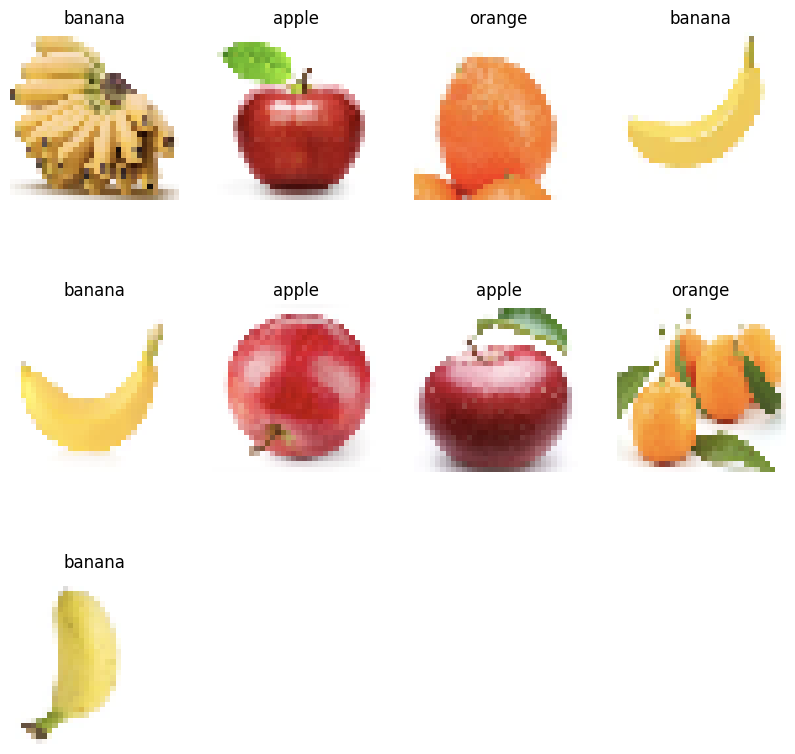

In [9]:
class_name = ["apple","banana","orange"]
plt.figure(figsize=(10,10))
for image_batch, label_batch in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3,4,i+1)
    plt.imshow(image_batch[i].numpy().astype("uint8"))
    plt.title(class_name[label_batch[i]])
    plt.axis("off")

In [14]:
model = tf.keras.Sequential(
    [
        tf.keras.layers.Rescaling( 1./255),
        tf.keras.layers.Conv2D(32,3,activation="relu"),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(64,3,activation="relu"),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(128,3,activation="relu"),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128,activation="softmax"),
        tf.keras.layers.Dense(3)
    ]
)

In [15]:
model.compile(
    optimizer="rmsprop",
    loss=tf.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

In [16]:
model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 314ms/step - accuracy: 0.3176 - loss: 1.0989 - val_accuracy: 0.3333 - val_loss: 1.0970
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - accuracy: 0.3438 - loss: 1.0947 - val_accuracy: 0.5000 - val_loss: 1.0894
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 109ms/step - accuracy: 0.4469 - loss: 1.0708 - val_accuracy: 0.4394 - val_loss: 1.0422
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 111ms/step - accuracy: 0.5471 - loss: 1.0275 - val_accuracy: 0.4697 - val_loss: 0.9896
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - accuracy: 0.5822 - loss: 0.9803 - val_accuracy: 0.5000 - val_loss: 1.0317
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - accuracy: 0.5372 - loss: 0.9984 - val_accuracy: 0.4545 - val_loss: 0.9828
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 164ms/step - accuracy: 0.6122 - loss: 0.9497 - val_accuracy: 0.4394 - val_loss: 1.0015
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 149ms/step - accuracy: 0.5963 - loss: 0.9484 - val_accuracy: 0.575

In [17]:
model.evaluate(test_ds)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.9068 - loss: 0.7435


[0.7506369948387146, 0.892307698726654]

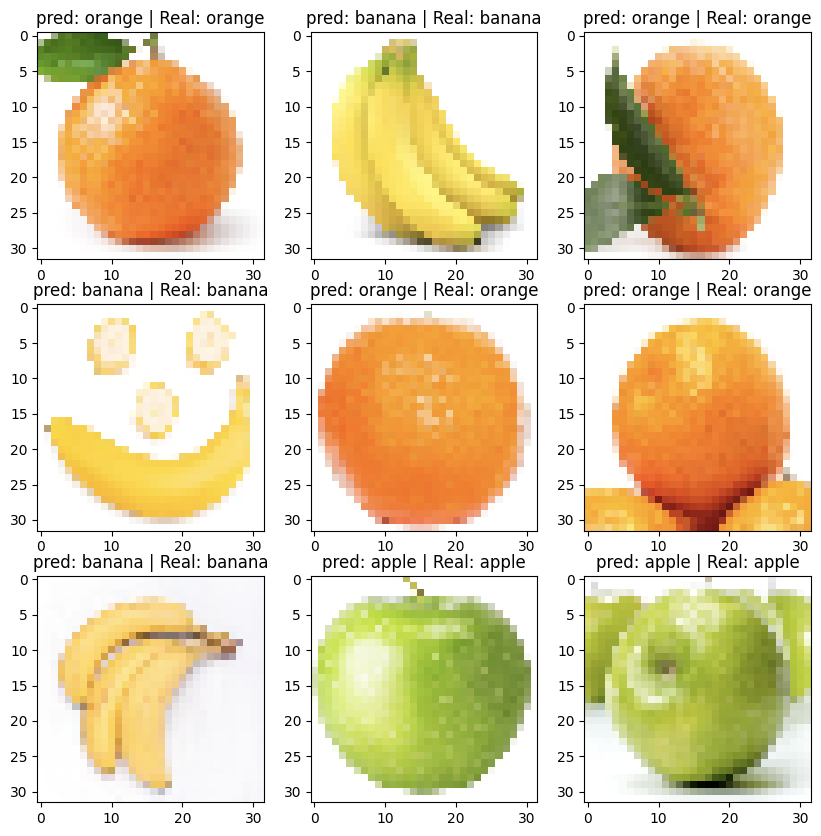

In [19]:
import numpy
plt.figure(figsize=(10,10))
for images, labels in test_ds.take(1):
    classification = model(images)
    #print classification

    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        index = numpy.argmax(classification[i])
        plt.title("pred: " + class_name[index] + " | Real: " + class_name[labels[i]])

In [20]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("model.tflite","wb") as f:
  f.write(tflite_model)

Saved artifact at '/tmp/tmpks7c_0rg'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name='keras_tensor_11')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  136709331856528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136709331859216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136709331857872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136709331858640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136709331858448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136709331859792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136709331859024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136709331860176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136709331858256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136709331860560: TensorSpec(shape=(), dtype=tf.resource, name=None)
